# Case XYZ Tech Company - People Analytics

## Análise de indicadores de recrutamento e seleção

### Contexto

A XYZ Tech Company atua no setor de tecnologia e enfrenta dificuldades
no preenchimento de vagas estratégicas. Algumas posições apresentam
tempo elevado de contratação, enquanto outras não são preenchidas
dentro do prazo esperado pelos gestores.

A demora nas contratações pode afetar a disponibilidade de profissionais
e a produtividade das áreas de negócio.

### Objetivo da análise

Analisar os dados de recrutamento e seleção da XYZ Tech Company para:

1. calcular o tempo médio de contratação da empresa;
2. identificar o percentual de vagas preenchidas dentro do prazo;
3. comparar o tempo médio de contratação entre os cargos;
4. identificar o cargo com maior taxa de atraso;
5. propor ações para melhorar o cumprimento dos prazos sem comprometer
   a qualidade das contratações.

### Indicadores principais

- **Tempo Médio de Contratação:** média de dias entre a abertura da vaga
  e a contratação efetiva.
- **Percentual de Vagas Preenchidas Dentro do Prazo:** proporção de vagas
  cuja contratação ocorreu até a data esperada.

### Escopo dos dados

O conjunto de dados contém dez vagas referentes aos seguintes cargos:

- Desenvolvedor Back-End;
- Analista de Dados;
- UX Designer.

Os dados foram disponibilizados no material da disciplina
**People Analytics e IA na Gestão de Talentos**, ministrada pelo
professor Danilo Garbazza.

### Ferramentas

A análise será desenvolvida no Google Colab utilizando Python e as
seguintes bibliotecas:

- pandas para estruturação e análise dos dados;
- Matplotlib e Seaborn para visualizações estáticas;
- Plotly para visualizações interativas.

### Premissas iniciais

- Os períodos serão calculados em dias corridos.
- Uma contratação será considerada dentro do prazo quando ocorrer na
  data esperada ou antes dela.
- As explicações sobre as causas dos resultados serão tratadas como
  hipóteses quando não houver variáveis suficientes para comprová-las.

## 1. Configuração e rastreabilidade do ambiente

Antes de iniciar a análise, registramos as principais informações do
ambiente de execução.

Essa verificação ajuda a:

- reproduzir a análise em outro computador;
- identificar diferenças entre versões das bibliotecas;
- facilitar a investigação de erros;
- documentar as condições em que os resultados foram produzidos.

O Google Colab já disponibiliza as bibliotecas necessárias. Portanto,
não serão executadas instalações desnecessárias nesta etapa.

In [15]:
from importlib.metadata import PackageNotFoundError, version
import platform
import sys


def obter_versao_pacote(nome_pacote: str) -> str:
    """Retorna a versão instalada de um pacote Python.

    Args:
        nome_pacote: Nome usado pelo pacote no gerenciador de dependências.

    Returns:
        Versão instalada ou uma mensagem informando que o pacote
        não foi encontrado.
    """
    try:
        return version(nome_pacote)
    except PackageNotFoundError:
        return "Pacote não encontrado"


# Os nomes abaixo correspondem aos registros dos pacotes instalados.
pacotes_analisados: dict[str, str] = {
    "Google Colab": "google-colab",
    "pandas": "pandas",
    "Matplotlib": "matplotlib",
    "Seaborn": "seaborn",
    "Plotly": "plotly",
}

print("INFORMAÇÕES DO AMBIENTE")
print("-" * 50)
print(f"Python: {platform.python_version()}")
print(f"Implementação: {platform.python_implementation()}")
print(f"Sistema operacional: {platform.platform()}")
print(f"Interpretador: {sys.executable}")

print("\nVERSÕES DAS BIBLIOTECAS")
print("-" * 50)

for nome_exibicao, nome_pacote in pacotes_analisados.items():
    versao_instalada = obter_versao_pacote(nome_pacote)
    print(f"{nome_exibicao}: {versao_instalada}")

INFORMAÇÕES DO AMBIENTE
--------------------------------------------------
Python: 3.12.13
Implementação: CPython
Sistema operacional: Linux-6.6.122+-x86_64-with-glibc2.35
Interpretador: /usr/bin/python3

VERSÕES DAS BIBLIOTECAS
--------------------------------------------------
Google Colab: 1.0.0
pandas: 2.2.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
Plotly: 5.24.1


## 2. Importação e configuração das bibliotecas

Nesta etapa, são carregadas as bibliotecas utilizadas durante a análise.

### Responsabilidade de cada biblioteca

- **pandas:** criação, limpeza, transformação e análise das tabelas;
- **Matplotlib:** construção e personalização de gráficos estáticos;
- **Seaborn:** criação de visualizações estatísticas;
- **Plotly:** construção de gráficos interativos;
- **IPython.display:** apresentação formatada de tabelas no notebook.

Os imports são organizados por origem, seguindo a PEP 8:

1. biblioteca-padrão do Python;
2. bibliotecas externas;
3. recursos específicos do ambiente do notebook.

Também são definidas configurações de exibição para facilitar a inspeção
dos dados sem alterar seus valores originais.

Avisos do Python não serão ocultados globalmente. Eles podem indicar
problemas de compatibilidade, conversão ou qualidade dos dados e devem
ser analisados quando aparecerem.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from IPython.display import display


# Identificação do projeto usada em títulos, arquivos e mensagens.
NOME_PROJETO: str = "Case XYZ Tech Company — People Analytics"
AUTOR_NOTEBOOK: str = "Fábio Andrade"

# Caminho-base do ambiente temporário utilizado pelo Google Colab.
DIRETORIO_TRABALHO: Path = Path.cwd()

# Configurações de visualização para facilitar a inspeção das tabelas.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 80)

print("AMBIENTE ANALÍTICO CONFIGURADO")
print("-" * 50)
print(f"Projeto: {NOME_PROJETO}")
print(f"Autor: {AUTOR_NOTEBOOK}")
print(f"Diretório de trabalho: {DIRETORIO_TRABALHO}")
print("\nBibliotecas importadas com sucesso:")
print("- pandas")
print("- Matplotlib")
print("- Seaborn")
print("- Plotly")

AMBIENTE ANALÍTICO CONFIGURADO
--------------------------------------------------
Projeto: Case XYZ Tech Company — People Analytics
Autor: Fábio Andrade
Diretório de trabalho: /content

Bibliotecas importadas com sucesso:
- pandas
- Matplotlib
- Seaborn
- Plotly


## 3. Criação do conjunto de dados

O material da disciplina apresenta dez vagas da XYZ Tech Company.

Como não existe uma planilha separada para este case, os registros são
transcritos diretamente da tabela oficial disponibilizada no material.

### Estrutura do conjunto de dados

Cada linha representa uma vaga e contém:

- identificador da vaga;
- cargo;
- data de abertura;
- data esperada para contratação;
- data efetiva da contratação.

As datas são registradas inicialmente no padrão ISO 8601
`AAAA-MM-DD`, reduzindo ambiguidades de interpretação.

Nesta etapa, os valores ainda são textos. A conversão para o tipo
`datetime` será realizada posteriormente, acompanhada de validações
específicas.

In [17]:
# Cada dicionário representa uma vaga apresentada no material oficial.
registros_vagas: list[dict[str, str]] = [
    {
        "id_vaga": "5193",
        "cargo": "Desenvolvedor Back-End",
        "data_abertura": "2025-07-05",
        "data_esperada_contratacao": "2025-10-01",
        "data_contratacao": "2025-10-10",
    },
    {
        "id_vaga": "8265",
        "cargo": "Desenvolvedor Back-End",
        "data_abertura": "2025-08-15",
        "data_esperada_contratacao": "2025-10-05",
        "data_contratacao": "2025-10-15",
    },
    {
        "id_vaga": "5487",
        "cargo": "Desenvolvedor Back-End",
        "data_abertura": "2025-09-10",
        "data_esperada_contratacao": "2025-09-30",
        "data_contratacao": "2025-10-15",
    },
    {
        "id_vaga": "3182",
        "cargo": "Analista de Dados",
        "data_abertura": "2025-07-20",
        "data_esperada_contratacao": "2025-10-10",
        "data_contratacao": "2025-10-05",
    },
    {
        "id_vaga": "6239",
        "cargo": "Analista de Dados",
        "data_abertura": "2025-08-05",
        "data_esperada_contratacao": "2025-11-20",
        "data_contratacao": "2025-11-22",
    },
    {
        "id_vaga": "2491",
        "cargo": "Analista de Dados",
        "data_abertura": "2025-09-30",
        "data_esperada_contratacao": "2025-12-10",
        "data_contratacao": "2025-12-08",
    },
    {
        "id_vaga": "9941",
        "cargo": "UX Designer",
        "data_abertura": "2025-06-12",
        "data_esperada_contratacao": "2025-10-05",
        "data_contratacao": "2025-10-02",
    },
    {
        "id_vaga": "4548",
        "cargo": "UX Designer",
        "data_abertura": "2025-07-18",
        "data_esperada_contratacao": "2025-11-25",
        "data_contratacao": "2025-11-28",
    },
    {
        "id_vaga": "5239",
        "cargo": "UX Designer",
        "data_abertura": "2025-08-25",
        "data_esperada_contratacao": "2025-12-20",
        "data_contratacao": "2025-12-18",
    },
    {
        "id_vaga": "6928",
        "cargo": "UX Designer",
        "data_abertura": "2025-09-05",
        "data_esperada_contratacao": "2025-12-15",
        "data_contratacao": "2025-12-20",
    },
]

# Cria a tabela analítica preservando a ordem dos registros do material.
df_vagas: pd.DataFrame = pd.DataFrame(registros_vagas)

# Define a estrutura mínima esperada antes de qualquer transformação.
colunas_esperadas: list[str] = [
    "id_vaga",
    "cargo",
    "data_abertura",
    "data_esperada_contratacao",
    "data_contratacao",
]

# As validações interrompem a execução caso a transcrição esteja incompleta.
assert list(df_vagas.columns) == colunas_esperadas, (
    "As colunas do DataFrame não correspondem à estrutura esperada."
)
assert df_vagas.shape == (10, 5), (
    "O dataset deve conter exatamente 10 registros e 5 colunas."
)

print("DATASET CRIADO COM SUCESSO")
print("-" * 50)
print(f"Quantidade de vagas: {df_vagas.shape[0]}")
print(f"Quantidade de colunas: {df_vagas.shape[1]}")
print(f"Identificadores únicos: {df_vagas['id_vaga'].nunique()}")

display(df_vagas)

DATASET CRIADO COM SUCESSO
--------------------------------------------------
Quantidade de vagas: 10
Quantidade de colunas: 5
Identificadores únicos: 10


,id_vaga,cargo,data_abertura,data_esperada_contratacao,data_contratacao
0,5193,Desenvolvedor Back-End,2025-07-05,2025-10-01,2025-10-10
1,8265,Desenvolvedor Back-End,2025-08-15,2025-10-05,2025-10-15
2,5487,Desenvolvedor Back-End,2025-09-10,2025-09-30,2025-10-15
3,3182,Analista de Dados,2025-07-20,2025-10-10,2025-10-05
4,6239,Analista de Dados,2025-08-05,2025-11-20,2025-11-22
5,2491,Analista de Dados,2025-09-30,2025-12-10,2025-12-08
6,9941,UX Designer,2025-06-12,2025-10-05,2025-10-02
7,4548,UX Designer,2025-07-18,2025-11-25,2025-11-28
8,5239,UX Designer,2025-08-25,2025-12-20,2025-12-18
9,6928,UX Designer,2025-09-05,2025-12-15,2025-12-20


## 4. Validação inicial da qualidade dos dados

Antes de transformar as datas e calcular os indicadores, é necessário
confirmar que o conjunto de dados possui uma estrutura confiável.

Nesta etapa, serão avaliados:

- valores ausentes;
- linhas completamente duplicadas;
- identificadores de vaga repetidos;
- espaços indevidos nos campos textuais;
- categorias existentes na coluna de cargo;
- tipos atuais das colunas.

Essas verificações fazem parte da qualidade dos dados e ajudam a evitar
resultados incorretos provocados por problemas de transcrição ou
estruturação.

Como o conjunto de dados foi digitado a partir do material oficial, a
validação também funciona como uma conferência da transcrição.

In [18]:
def resumir_qualidade_dados(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Cria um resumo de qualidade para cada coluna do DataFrame.

    Args:
        dataframe: Tabela que será avaliada.

    Returns:
        DataFrame com tipo, quantidade de valores ausentes, valores
        únicos e percentual de ausência por coluna.
    """
    quantidade_linhas: int = len(dataframe)

    resumo: pd.DataFrame = pd.DataFrame(
        {
            "tipo_dado": dataframe.dtypes.astype(str),
            "valores_ausentes": dataframe.isna().sum(),
            "percentual_ausentes": (
                dataframe.isna().sum()
                .div(quantidade_linhas)
                .mul(100)
                .round(2)
            ),
            "valores_unicos": dataframe.nunique(dropna=False),
        }
    )

    return resumo


# Verifica problemas estruturais que poderiam comprometer a análise.
quantidade_duplicados: int = int(df_vagas.duplicated().sum())
quantidade_ids_duplicados: int = int(
    df_vagas["id_vaga"].duplicated().sum()
)

# Detecta espaços no início ou no fim dos campos de texto.
colunas_textuais: list[str] = [
    "id_vaga",
    "cargo",
    "data_abertura",
    "data_esperada_contratacao",
    "data_contratacao",
]

espacos_externos: dict[str, int] = {
    coluna: int(
        df_vagas[coluna]
        .astype(str)
        .ne(df_vagas[coluna].astype(str).str.strip())
        .sum()
    )
    for coluna in colunas_textuais
}

resumo_qualidade: pd.DataFrame = resumir_qualidade_dados(df_vagas)

print("VALIDAÇÃO INICIAL DA QUALIDADE DOS DADOS")
print("-" * 60)
print(f"Linhas duplicadas: {quantidade_duplicados}")
print(f"IDs de vaga duplicados: {quantidade_ids_duplicados}")
print(f"Total de valores ausentes: {int(df_vagas.isna().sum().sum())}")

print("\nESPAÇOS EXTERNOS POR COLUNA")
print("-" * 60)

for coluna, quantidade in espacos_externos.items():
    print(f"{coluna}: {quantidade}")

print("\nCARGOS IDENTIFICADOS")
print("-" * 60)

for cargo, quantidade in df_vagas["cargo"].value_counts().items():
    print(f"{cargo}: {quantidade} vaga(s)")

print("\nRESUMO POR COLUNA")
display(resumo_qualidade)

VALIDAÇÃO INICIAL DA QUALIDADE DOS DADOS
------------------------------------------------------------
Linhas duplicadas: 0
IDs de vaga duplicados: 0
Total de valores ausentes: 0

ESPAÇOS EXTERNOS POR COLUNA
------------------------------------------------------------
id_vaga: 0
cargo: 0
data_abertura: 0
data_esperada_contratacao: 0
data_contratacao: 0

CARGOS IDENTIFICADOS
------------------------------------------------------------
UX Designer: 4 vaga(s)
Desenvolvedor Back-End: 3 vaga(s)
Analista de Dados: 3 vaga(s)

RESUMO POR COLUNA


,tipo_dado,valores_ausentes,percentual_ausentes,valores_unicos
id_vaga,object,0,0.0,10
cargo,object,0,0.0,3
data_abertura,object,0,0.0,10
data_esperada_contratacao,object,0,0.0,9
data_contratacao,object,0,0.0,9


## 5. Conversão e validação das datas

As datas foram inicialmente armazenadas como texto para preservar a
transcrição do material oficial.

Nesta etapa, elas serão convertidas para o tipo `datetime`, que permite:

- calcular diferenças entre datas;
- ordenar os registros cronologicamente;
- identificar prazos e atrasos;
- criar indicadores de recrutamento e seleção;
- produzir gráficos temporais.

A conversão será feita com formato explícito `AAAA-MM-DD`.

Também serão verificadas regras cronológicas básicas:

1. a data de abertura não pode ocorrer depois da contratação;
2. a data de abertura não pode ocorrer depois da data esperada;
3. nenhuma data pode permanecer inválida após a conversão.

Essas validações não substituem uma auditoria completa, mas reduzem o
risco de calcular indicadores com datas inconsistentes.

In [19]:
# Mantém o DataFrame transcrito intacto e cria uma cópia para análise.
df_analise: pd.DataFrame = df_vagas.copy()

colunas_data: list[str] = [
    "data_abertura",
    "data_esperada_contratacao",
    "data_contratacao",
]

# O formato explícito evita interpretações ambíguas entre dia e mês.
for coluna in colunas_data:
    df_analise[coluna] = pd.to_datetime(
        df_analise[coluna],
        format="%Y-%m-%d",
        errors="raise",
    )

# Valida se todas as colunas foram convertidas para tipos de data.
for coluna in colunas_data:
    assert pd.api.types.is_datetime64_any_dtype(df_analise[coluna]), (
        f"A coluna {coluna} não foi convertida corretamente para datetime."
    )

# Identifica relações cronológicas que seriam incompatíveis com o case.
abertura_apos_contratacao: pd.Series = (
    df_analise["data_abertura"] > df_analise["data_contratacao"]
)

abertura_apos_data_esperada: pd.Series = (
    df_analise["data_abertura"]
    > df_analise["data_esperada_contratacao"]
)

quantidade_datas_invalidas: int = int(
    df_analise[colunas_data].isna().sum().sum()
)
quantidade_abertura_apos_contratacao: int = int(
    abertura_apos_contratacao.sum()
)
quantidade_abertura_apos_esperada: int = int(
    abertura_apos_data_esperada.sum()
)

print("CONVERSÃO E VALIDAÇÃO DAS DATAS")
print("-" * 60)
print(f"Datas inválidas após conversão: {quantidade_datas_invalidas}")
print(
    "Aberturas posteriores à contratação: "
    f"{quantidade_abertura_apos_contratacao}"
)
print(
    "Aberturas posteriores à data esperada: "
    f"{quantidade_abertura_apos_esperada}"
)

print("\nINTERVALO TEMPORAL DO DATASET")
print("-" * 60)
print(
    "Primeira abertura: "
    f"{df_analise['data_abertura'].min().date()}"
)
print(
    "Última abertura: "
    f"{df_analise['data_abertura'].max().date()}"
)
print(
    "Primeira contratação: "
    f"{df_analise['data_contratacao'].min().date()}"
)
print(
    "Última contratação: "
    f"{df_analise['data_contratacao'].max().date()}"
)

print("\nTIPOS DAS COLUNAS")
display(df_analise.dtypes.to_frame(name="tipo_dado"))

print("\nAMOSTRA APÓS A CONVERSÃO")
display(df_analise.head())

CONVERSÃO E VALIDAÇÃO DAS DATAS
------------------------------------------------------------
Datas inválidas após conversão: 0
Aberturas posteriores à contratação: 0
Aberturas posteriores à data esperada: 0

INTERVALO TEMPORAL DO DATASET
------------------------------------------------------------
Primeira abertura: 2025-06-12
Última abertura: 2025-09-30
Primeira contratação: 2025-10-02
Última contratação: 2025-12-20

TIPOS DAS COLUNAS


,tipo_dado
id_vaga,object
cargo,object
data_abertura,datetime64[ns]
data_esperada_contratacao,datetime64[ns]
data_contratacao,datetime64[ns]



AMOSTRA APÓS A CONVERSÃO


,id_vaga,cargo,data_abertura,data_esperada_contratacao,data_contratacao
0,5193,Desenvolvedor Back-End,2025-07-05,2025-10-01,2025-10-10
1,8265,Desenvolvedor Back-End,2025-08-15,2025-10-05,2025-10-15
2,5487,Desenvolvedor Back-End,2025-09-10,2025-09-30,2025-10-15
3,3182,Analista de Dados,2025-07-20,2025-10-10,2025-10-05
4,6239,Analista de Dados,2025-08-05,2025-11-20,2025-11-22


## 6. Engenharia das variáveis de análise

As datas isoladas não respondem diretamente às perguntas do exercício.

Por isso, serão criadas variáveis derivadas que representem:

- a duração total do processo de contratação;
- a diferença entre a data efetiva e a data esperada;
- o cumprimento ou não do prazo;
- a quantidade de dias de atraso;
- a quantidade de dias de antecipação.

### Regras de negócio

#### Tempo de contratação

Calculado pela diferença entre a data da contratação e a data de abertura
da vaga.

#### Desvio do prazo

Calculado pela diferença entre a data da contratação e a data esperada.

- valor positivo: contratação atrasada;
- valor igual a zero: contratação exatamente no prazo;
- valor negativo: contratação antecipada.

#### Classificação do prazo

Uma vaga será considerada dentro do prazo quando a contratação ocorrer
na data esperada ou antes dela.

As análises utilizam dias corridos, conforme a premissa definida no
início do notebook.

In [20]:
# Calcula a duração total do processo seletivo em dias corridos.
df_analise["tempo_contratacao_dias"] = (
    df_analise["data_contratacao"] - df_analise["data_abertura"]
).dt.days

# Mede o desvio entre a contratação efetiva e a data planejada.
df_analise["dias_desvio_prazo"] = (
    df_analise["data_contratacao"]
    - df_analise["data_esperada_contratacao"]
).dt.days

# Uma contratação na data esperada também é considerada dentro do prazo.
df_analise["dentro_prazo"] = (
    df_analise["data_contratacao"]
    <= df_analise["data_esperada_contratacao"]
)

# Cria um rótulo legível para tabelas e gráficos.
df_analise["status_prazo"] = df_analise["dentro_prazo"].map(
    {
        True: "Dentro do prazo",
        False: "Atrasada",
    }
)

# Separa atraso e antecipação em colunas não negativas.
df_analise["dias_atraso"] = (
    df_analise["dias_desvio_prazo"].clip(lower=0)
)

df_analise["dias_antecipacao"] = (
    -df_analise["dias_desvio_prazo"].clip(upper=0)
)

# Validações de coerência das variáveis derivadas.
assert (df_analise["tempo_contratacao_dias"] >= 0).all(), (
    "Existe tempo de contratação negativo."
)

assert (df_analise["dias_atraso"] >= 0).all(), (
    "Existe valor negativo na coluna de atraso."
)

assert (df_analise["dias_antecipacao"] >= 0).all(), (
    "Existe valor negativo na coluna de antecipação."
)

assert (
    df_analise["dentro_prazo"]
    == (df_analise["dias_desvio_prazo"] <= 0)
).all(), "A classificação de prazo está inconsistente."

colunas_resultado: list[str] = [
    "id_vaga",
    "cargo",
    "tempo_contratacao_dias",
    "dias_desvio_prazo",
    "status_prazo",
    "dias_atraso",
    "dias_antecipacao",
]

print("VARIÁVEIS DERIVADAS CRIADAS")
print("-" * 60)
print(f"Total de vagas: {len(df_analise)}")
print(f"Vagas dentro do prazo: {int(df_analise['dentro_prazo'].sum())}")
print(
    "Vagas atrasadas: "
    f"{int((~df_analise['dentro_prazo']).sum())}"
)

display(df_analise[colunas_resultado])

VARIÁVEIS DERIVADAS CRIADAS
------------------------------------------------------------
Total de vagas: 10
Vagas dentro do prazo: 4
Vagas atrasadas: 6


,id_vaga,cargo,tempo_contratacao_dias,dias_desvio_prazo,status_prazo,dias_atraso,dias_antecipacao
0,5193,Desenvolvedor Back-End,97,9,Atrasada,9,0
1,8265,Desenvolvedor Back-End,61,10,Atrasada,10,0
2,5487,Desenvolvedor Back-End,35,15,Atrasada,15,0
3,3182,Analista de Dados,77,-5,Dentro do prazo,0,5
4,6239,Analista de Dados,109,2,Atrasada,2,0
5,2491,Analista de Dados,69,-2,Dentro do prazo,0,2
6,9941,UX Designer,112,-3,Dentro do prazo,0,3
7,4548,UX Designer,133,3,Atrasada,3,0
8,5239,UX Designer,115,-2,Dentro do prazo,0,2
9,6928,UX Designer,106,5,Atrasada,5,0


## 7. Indicadores gerais de recrutamento e seleção

Nesta etapa, são calculados os dois indicadores principais solicitados
pelo exercício.

### Tempo Médio de Contratação

Representa a média de dias corridos entre a abertura da vaga e a
contratação efetiva.

A média resume o desempenho geral, mas pode ser influenciada por
processos muito longos ou muito curtos. Por isso, também será calculada
a mediana.

### Percentual de Vagas Preenchidas Dentro do Prazo

Representa a proporção de contratações realizadas na data esperada ou
antes dela.

O indicador é calculado pela divisão:

> quantidade de vagas dentro do prazo ÷ total de vagas × 100

Esses resultados correspondem ao nível descritivo de People Analytics:
eles mostram o que aconteceu no processo de recrutamento e seleção.

In [21]:
def calcular_percentual(parte: int, total: int) -> float:
    """Calcula a participação percentual de uma quantidade.

    Args:
        parte: Quantidade pertencente ao grupo analisado.
        total: Quantidade total de registros.

    Returns:
        Percentual arredondado para duas casas decimais.

    Raises:
        ValueError: Se o total informado for igual ou menor que zero.
    """
    if total <= 0:
        raise ValueError("O total deve ser maior que zero.")

    return round((parte / total) * 100, 2)


# Quantidades básicas utilizadas no cálculo dos indicadores.
total_vagas: int = len(df_analise)
vagas_dentro_prazo: int = int(df_analise["dentro_prazo"].sum())
vagas_atrasadas: int = total_vagas - vagas_dentro_prazo

# Indicadores principais solicitados pelo exercício.
tempo_medio_contratacao: float = round(
    df_analise["tempo_contratacao_dias"].mean(),
    2,
)

percentual_dentro_prazo: float = calcular_percentual(
    vagas_dentro_prazo,
    total_vagas,
)

# Medidas auxiliares para avaliar a distribuição dos tempos.
tempo_mediano_contratacao: float = round(
    df_analise["tempo_contratacao_dias"].median(),
    2,
)

menor_tempo_contratacao: int = int(
    df_analise["tempo_contratacao_dias"].min()
)

maior_tempo_contratacao: int = int(
    df_analise["tempo_contratacao_dias"].max()
)

amplitude_tempo_contratacao: int = (
    maior_tempo_contratacao - menor_tempo_contratacao
)

# Validações independentes das regras de cálculo.
assert vagas_dentro_prazo + vagas_atrasadas == total_vagas, (
    "A soma das classificações de prazo não corresponde ao total."
)

assert 0 <= percentual_dentro_prazo <= 100, (
    "O percentual calculado está fora do intervalo válido."
)

assert tempo_medio_contratacao >= 0, (
    "O tempo médio de contratação não pode ser negativo."
)

print("INDICADORES GERAIS")
print("-" * 60)
print(
    f"Tempo médio de contratação: "
    f"{tempo_medio_contratacao:.2f} dias"
)
print(
    f"Tempo mediano de contratação: "
    f"{tempo_mediano_contratacao:.2f} dias"
)
print(f"Menor tempo de contratação: {menor_tempo_contratacao} dias")
print(f"Maior tempo de contratação: {maior_tempo_contratacao} dias")
print(f"Amplitude dos tempos: {amplitude_tempo_contratacao} dias")

print("\nCUMPRIMENTO DO PRAZO")
print("-" * 60)
print(f"Total de vagas: {total_vagas}")
print(f"Vagas dentro do prazo: {vagas_dentro_prazo}")
print(f"Vagas atrasadas: {vagas_atrasadas}")
print(
    f"Percentual de vagas dentro do prazo: "
    f"{percentual_dentro_prazo:.2f}%"
)

INDICADORES GERAIS
------------------------------------------------------------
Tempo médio de contratação: 91.40 dias
Tempo mediano de contratação: 101.50 dias
Menor tempo de contratação: 35 dias
Maior tempo de contratação: 133 dias
Amplitude dos tempos: 98 dias

CUMPRIMENTO DO PRAZO
------------------------------------------------------------
Total de vagas: 10
Vagas dentro do prazo: 4
Vagas atrasadas: 6
Percentual de vagas dentro do prazo: 40.00%


## 8. Comparação dos indicadores por cargo

A análise geral mostra o desempenho consolidado da empresa, mas não
permite identificar quais cargos concentram os maiores problemas.

Nesta etapa, os indicadores serão agrupados por cargo para comparar:

- duração média dos processos seletivos;
- cumprimento dos prazos;
- intensidade dos atrasos;
- dispersão entre as vagas de cada função.

A comparação deve considerar duas dimensões diferentes:

1. **velocidade do processo:** medida pelo tempo médio de contratação;
2. **cumprimento do planejamento:** medido pela taxa de atraso.

Um cargo pode apresentar contratação rápida e, mesmo assim, ter alto
percentual de atraso caso os prazos planejados sejam muito curtos.

In [22]:
def media_atraso_vagas_atrasadas(serie: pd.Series) -> float:
    """Calcula o atraso médio considerando apenas valores positivos.

    Args:
        serie: Série contendo a quantidade de dias de atraso.

    Returns:
        Média dos atrasos positivos ou zero quando não houver atraso.
    """
    atrasos_positivos: pd.Series = serie[serie > 0]

    if atrasos_positivos.empty:
        return 0.0

    return round(float(atrasos_positivos.mean()), 2)


# Consolida os principais indicadores de recrutamento por cargo.
resumo_por_cargo: pd.DataFrame = (
    df_analise.groupby("cargo", as_index=False)
    .agg(
        quantidade_vagas=("id_vaga", "count"),
        tempo_medio_dias=("tempo_contratacao_dias", "mean"),
        tempo_mediano_dias=("tempo_contratacao_dias", "median"),
        menor_tempo_dias=("tempo_contratacao_dias", "min"),
        maior_tempo_dias=("tempo_contratacao_dias", "max"),
        vagas_dentro_prazo=("dentro_prazo", "sum"),
        atraso_medio_vagas_atrasadas=(
            "dias_atraso",
            media_atraso_vagas_atrasadas,
        ),
    )
)

# Deriva quantidades e percentuais a partir do resumo agrupado.
resumo_por_cargo["vagas_atrasadas"] = (
    resumo_por_cargo["quantidade_vagas"]
    - resumo_por_cargo["vagas_dentro_prazo"]
)

resumo_por_cargo["percentual_dentro_prazo"] = (
    resumo_por_cargo["vagas_dentro_prazo"]
    .div(resumo_por_cargo["quantidade_vagas"])
    .mul(100)
)

resumo_por_cargo["percentual_atraso"] = (
    resumo_por_cargo["vagas_atrasadas"]
    .div(resumo_por_cargo["quantidade_vagas"])
    .mul(100)
)

# Arredonda apenas as colunas contínuas para melhorar a apresentação.
colunas_arredondamento: list[str] = [
    "tempo_medio_dias",
    "tempo_mediano_dias",
    "percentual_dentro_prazo",
    "percentual_atraso",
    "atraso_medio_vagas_atrasadas",
]

resumo_por_cargo[colunas_arredondamento] = (
    resumo_por_cargo[colunas_arredondamento].round(2)
)

# Ordena do processo mais rápido para o mais lento.
resumo_por_cargo = resumo_por_cargo.sort_values(
    by="tempo_medio_dias",
    ascending=True,
).reset_index(drop=True)

cargo_menor_tempo_medio: str = resumo_por_cargo.loc[
    resumo_por_cargo["tempo_medio_dias"].idxmin(),
    "cargo",
]

cargo_maior_taxa_atraso: str = resumo_por_cargo.loc[
    resumo_por_cargo["percentual_atraso"].idxmax(),
    "cargo",
]

# Validações para conferir a consistência do agrupamento.
assert resumo_por_cargo["quantidade_vagas"].sum() == total_vagas, (
    "A soma das vagas por cargo não corresponde ao total."
)

assert (
    resumo_por_cargo["vagas_dentro_prazo"].sum()
    == vagas_dentro_prazo
), "A soma das vagas dentro do prazo está inconsistente."

assert (
    resumo_por_cargo["vagas_atrasadas"].sum()
    == vagas_atrasadas
), "A soma das vagas atrasadas está inconsistente."

print("INDICADORES POR CARGO")
print("-" * 70)
print(f"Cargo com menor tempo médio: {cargo_menor_tempo_medio}")
print(f"Cargo com maior taxa de atraso: {cargo_maior_taxa_atraso}")

display(resumo_por_cargo)

INDICADORES POR CARGO
----------------------------------------------------------------------
Cargo com menor tempo médio: Desenvolvedor Back-End
Cargo com maior taxa de atraso: Desenvolvedor Back-End


,cargo,quantidade_vagas,tempo_medio_dias,tempo_mediano_dias,menor_tempo_dias,maior_tempo_dias,vagas_dentro_prazo,atraso_medio_vagas_atrasadas,vagas_atrasadas,percentual_dentro_prazo,percentual_atraso
0,Desenvolvedor Back-End,3,64.33,61.0,35,97,0,11.33,3,0.00,100.00
1,Analista de Dados,3,85.00,77.0,69,109,2,2.00,1,66.67,33.33
2,UX Designer,4,116.50,113.5,106,133,2,4.00,2,50.00,50.00


## 9. Visualização do tempo médio de contratação por cargo

O gráfico a seguir compara o tempo médio de contratação entre os cargos.

A barra representa a média de dias corridos entre a abertura e a
contratação efetiva.

A linha horizontal indica o tempo médio geral da empresa, permitindo
identificar quais cargos estão acima ou abaixo do desempenho consolidado.

Essa visualização ajuda a responder qual cargo apresentou o processo
mais rápido e qual apresentou o processo mais demorado.

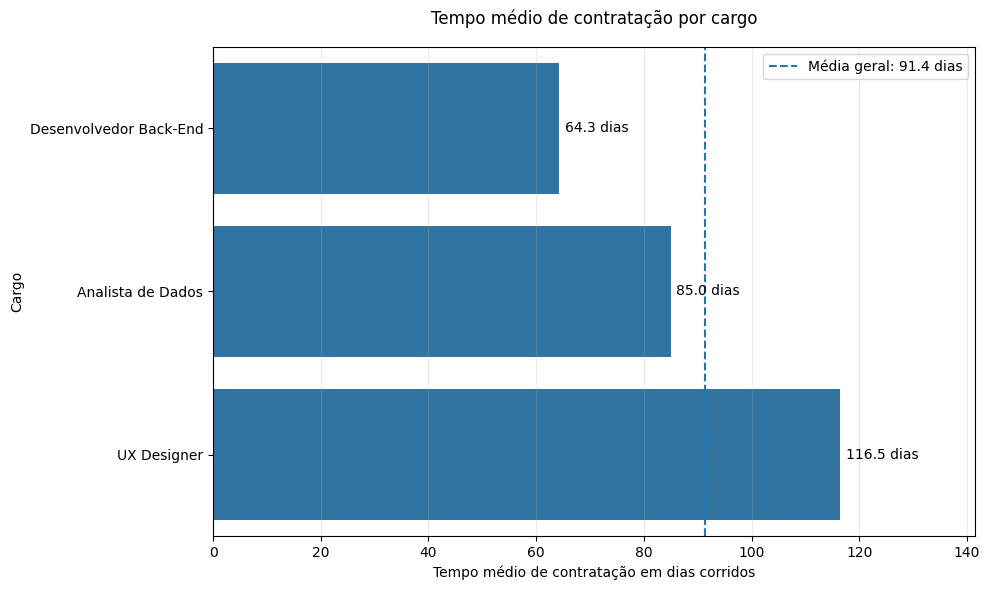

In [23]:
# Ordena os cargos do menor para o maior tempo médio.
dados_grafico_tempo: pd.DataFrame = resumo_por_cargo.sort_values(
    by="tempo_medio_dias",
    ascending=True,
).copy()

figura, eixo = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=dados_grafico_tempo,
    x="tempo_medio_dias",
    y="cargo",
    ax=eixo,
)

# A linha de referência facilita a comparação com o resultado geral.
eixo.axvline(
    x=tempo_medio_contratacao,
    linestyle="--",
    linewidth=1.5,
    label=f"Média geral: {tempo_medio_contratacao:.1f} dias",
)

# Adiciona os valores ao final de cada barra.
for indice, valor in enumerate(dados_grafico_tempo["tempo_medio_dias"]):
    eixo.text(
        valor + 1,
        indice,
        f"{valor:.1f} dias",
        va="center",
    )

eixo.set_title(
    "Tempo médio de contratação por cargo",
    pad=16,
)
eixo.set_xlabel("Tempo médio de contratação em dias corridos")
eixo.set_ylabel("Cargo")
eixo.legend()
eixo.grid(axis="x", alpha=0.25)

# Amplia o limite para evitar que os rótulos sejam cortados.
limite_superior: float = (
    dados_grafico_tempo["tempo_medio_dias"].max() + 25
)
eixo.set_xlim(0, limite_superior)

plt.tight_layout()
plt.show()

## 10. Visualização do cumprimento de prazo por cargo

O gráfico a seguir compara a proporção de vagas concluídas dentro do
prazo e em atraso para cada cargo.

A visualização utiliza percentuais, pois os cargos possuem quantidades
diferentes de vagas.

Essa comparação evita interpretar apenas valores absolutos e permite
identificar o cargo com maior taxa de atraso.

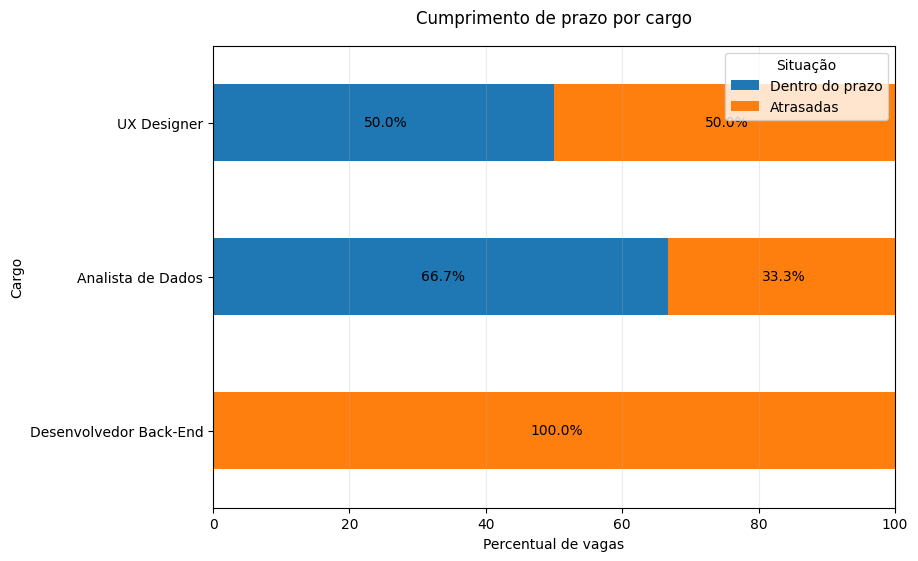

In [24]:
# Organiza os percentuais necessários para o gráfico empilhado.
dados_prazo_cargo: pd.DataFrame = (
    resumo_por_cargo[
        [
            "cargo",
            "percentual_dentro_prazo",
            "percentual_atraso",
        ]
    ]
    .set_index("cargo")
    .copy()
)

figura, eixo = plt.subplots(figsize=(11, 6))

dados_prazo_cargo.plot(
    kind="barh",
    stacked=True,
    ax=eixo,
)

eixo.set_title(
    "Cumprimento de prazo por cargo",
    pad=16,
)
eixo.set_xlabel("Percentual de vagas")
eixo.set_ylabel("Cargo")
eixo.set_xlim(0, 100)
eixo.legend(
    [
        "Dentro do prazo",
        "Atrasadas",
    ],
    title="Situação",
    loc="upper right",
)

# Exibe rótulos apenas em segmentos com valor maior que zero.
for container in eixo.containers:
    valores_segmentos = [barra.get_width() for barra in container]

    rotulos = [
        f"{valor:.1f}%"
        if valor > 0
        else ""
        for valor in valores_segmentos
    ]

    eixo.bar_label(
        container,
        labels=rotulos,
        label_type="center",
        padding=2,
    )

eixo.grid(axis="x", alpha=0.25)

# Reserva espaço adicional à esquerda para nomes de cargos longos.
figura.subplots_adjust(left=0.28)

plt.show()

## 11. Comparação entre prazo planejado e tempo real por vaga

Os indicadores agregados resumem o comportamento geral, mas podem
esconder diferenças importantes entre as vagas.

Nesta visualização, cada vaga será comparada em duas dimensões:

- **tempo planejado:** diferença entre a data de abertura e a data
  esperada para contratação;
- **tempo real:** diferença entre a data de abertura e a data efetiva
  da contratação.

Quando o tempo real ultrapassa o tempo planejado, a vaga foi concluída
com atraso. Quando fica abaixo, a contratação ocorreu antes do prazo.

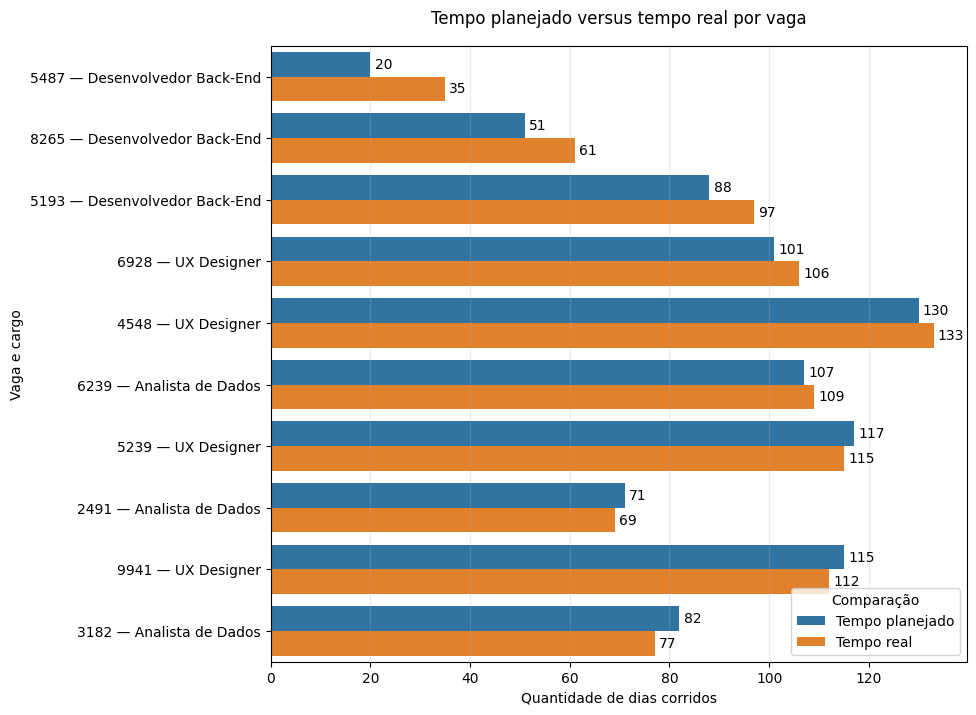

In [25]:
# Calcula o tempo originalmente planejado para cada processo seletivo.
df_analise["tempo_planejado_dias"] = (
    df_analise["data_esperada_contratacao"]
    - df_analise["data_abertura"]
).dt.days

# Cria um rótulo único para facilitar a identificação de cada vaga.
df_analise["rotulo_vaga"] = (
    df_analise["id_vaga"]
    + " — "
    + df_analise["cargo"]
)

# Ordena da maior diferença de prazo para a menor.
dados_comparacao_vagas: pd.DataFrame = df_analise.sort_values(
    by="dias_desvio_prazo",
    ascending=False,
).copy()

# Converte os dados para o formato longo exigido pelo Seaborn.
dados_comparacao_longos: pd.DataFrame = dados_comparacao_vagas.melt(
    id_vars=[
        "rotulo_vaga",
        "cargo",
        "dias_desvio_prazo",
    ],
    value_vars=[
        "tempo_planejado_dias",
        "tempo_contratacao_dias",
    ],
    var_name="tipo_tempo",
    value_name="quantidade_dias",
)

rotulos_tipo_tempo: dict[str, str] = {
    "tempo_planejado_dias": "Tempo planejado",
    "tempo_contratacao_dias": "Tempo real",
}

dados_comparacao_longos["tipo_tempo"] = (
    dados_comparacao_longos["tipo_tempo"].map(rotulos_tipo_tempo)
)

figura, eixo = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=dados_comparacao_longos,
    x="quantidade_dias",
    y="rotulo_vaga",
    hue="tipo_tempo",
    ax=eixo,
)

eixo.set_title(
    "Tempo planejado versus tempo real por vaga",
    pad=16,
)
eixo.set_xlabel("Quantidade de dias corridos")
eixo.set_ylabel("Vaga e cargo")
eixo.legend(
    title="Comparação",
    loc="lower right",
)
eixo.grid(axis="x", alpha=0.25)

# Exibe os valores ao final das barras para facilitar a leitura.
for container in eixo.containers:
    eixo.bar_label(
        container,
        fmt="%.0f",
        padding=3,
    )

# Reserva espaço para os rótulos completos das vagas.
figura.subplots_adjust(left=0.32)

plt.show()

## 12. Visualização interativa do desvio de prazo

A visualização interativa apresenta a diferença entre a data efetiva de
contratação e a data esperada para cada vaga.

### Interpretação

- valores positivos indicam atraso;
- valores negativos indicam antecipação;
- valor igual a zero indica contratação exatamente na data prevista.

O gráfico permite explorar cada vaga individualmente e observar os
resultados por cargo por meio das informações exibidas ao passar o mouse.

In [26]:
# Ordena as vagas da maior antecipação para o maior atraso.
dados_grafico_interativo: pd.DataFrame = df_analise.sort_values(
    by="dias_desvio_prazo",
    ascending=True,
).copy()

# Cria uma classificação específica para facilitar a leitura do gráfico.
dados_grafico_interativo["situacao_desvio"] = (
    dados_grafico_interativo["dias_desvio_prazo"]
    .apply(
        lambda valor: (
            "Atrasada"
            if valor > 0
            else "Dentro do prazo"
        )
    )
)

figura_interativa = px.bar(
    dados_grafico_interativo,
    x="dias_desvio_prazo",
    y="rotulo_vaga",
    orientation="h",
    color="situacao_desvio",
    text="dias_desvio_prazo",
    hover_data={
        "cargo": True,
        "data_abertura": "|%d/%m/%Y",
        "data_esperada_contratacao": "|%d/%m/%Y",
        "data_contratacao": "|%d/%m/%Y",
        "tempo_contratacao_dias": True,
        "dias_desvio_prazo": True,
        "situacao_desvio": False,
        "rotulo_vaga": False,
    },
    labels={
        "dias_desvio_prazo": "Desvio do prazo em dias",
        "rotulo_vaga": "Vaga e cargo",
        "situacao_desvio": "Situação",
        "tempo_contratacao_dias": "Tempo de contratação",
        "cargo": "Cargo",
        "data_abertura": "Data de abertura",
        "data_esperada_contratacao": "Data esperada",
        "data_contratacao": "Data de contratação",
    },
    title="Desvio do prazo de contratação por vaga",
)

# Ajusta os rótulos para exibir sinal positivo apenas nos atrasos.
figura_interativa.update_traces(
    texttemplate="%{x:+.0f}",
    textposition="outside",
    cliponaxis=False,
)

# A linha vertical em zero separa antecipações de atrasos.
figura_interativa.add_vline(
    x=0,
    line_dash="dash",
    annotation_text="Prazo planejado",
    annotation_position="top",
)

figura_interativa.update_layout(
    height=650,
    xaxis_title="Dias em relação ao prazo esperado",
    yaxis_title="Vaga e cargo",
    legend_title="Situação",
    hovermode="closest",
    margin={
        "l": 220,
        "r": 60,
        "t": 80,
        "b": 60,
    },
)

figura_interativa.show()

## 13. Respostas às questões 1 e 2

### 1. Qual o Tempo Médio de Contratação geral da empresa?

O Tempo Médio de Contratação da XYZ Tech Company foi de
**91,4 dias corridos**.

Esse indicador representa a média do período entre a abertura de cada
vaga e a contratação efetiva.

A mediana foi de **101,5 dias**, valor superior à média. Isso ocorre
porque algumas contratações mais rápidas, especialmente a vaga com
35 dias, reduziram o valor médio geral.

### 2. Qual o percentual de vagas preenchidas dentro do prazo?

Das 10 vagas analisadas:

- 4 foram preenchidas dentro do prazo;
- 6 foram preenchidas com atraso.

Portanto, o percentual de vagas preenchidas dentro do prazo foi de
**40%**.

Consequentemente, **60% das vagas ultrapassaram a data esperada para
contratação**.

### Interpretação gerencial

Os resultados indicam que a empresa apresenta um processo seletivo
relativamente longo e baixa aderência aos prazos planejados.

O principal problema não está apenas na duração média das contratações,
mas também na diferença entre o planejamento e a execução.

Esses indicadores devem ser analisados em conjunto com os resultados
por cargo, pois diferentes funções apresentam comportamentos distintos.

## 14. Respostas às questões 3 e 4

### 3. Qual cargo teve o menor tempo médio de contratação?

O cargo com menor tempo médio de contratação foi
**Desenvolvedor Back-End**, com média de **64,33 dias corridos**.

Comparação dos tempos médios:

- Desenvolvedor Back-End: **64,33 dias**;
- Analista de Dados: **85,00 dias**;
- UX Designer: **116,50 dias**.

Portanto, o processo de contratação para Desenvolvedor Back-End foi,
em média, o mais rápido entre os cargos analisados.

#### Possíveis hipóteses para essa maior agilidade

O dataset não contém variáveis suficientes para comprovar as causas.
Entretanto, algumas hipóteses plausíveis são:

- processo seletivo com etapas mais objetivas;
- definição mais clara dos requisitos técnicos;
- maior disponibilidade de candidatos no período analisado;
- menor quantidade de níveis de aprovação;
- uso de banco de talentos já existente;
- maior urgência das áreas demandantes.

Essas possibilidades devem ser tratadas como hipóteses, pois não há no
dataset informações sobre candidatos, etapas, salários, aprovações ou
origem das contratações.

---

### 4. Qual cargo teve a maior taxa de atraso nas contratações?

O cargo com maior taxa de atraso foi também
**Desenvolvedor Back-End**.

As três vagas desse cargo foram concluídas após a data esperada:

- 3 vagas analisadas;
- 3 vagas atrasadas;
- taxa de atraso de **100%**;
- atraso médio de **11,33 dias** entre as vagas atrasadas.

Comparação das taxas de atraso:

- Desenvolvedor Back-End: **100%**;
- UX Designer: **50%**;
- Analista de Dados: **33,33%**.

#### Interpretação

O resultado mostra que velocidade e cumprimento de prazo são dimensões
diferentes.

Desenvolvedor Back-End apresentou o menor tempo médio de contratação,
mas todas as vagas ultrapassaram o prazo planejado.

Isso sugere que os prazos definidos para esse cargo podem ter sido mais
curtos ou menos realistas em relação ao tempo necessário para concluir
o processo.

#### Possíveis fatores associados ao atraso

Algumas hipóteses são:

- prazo inicial excessivamente agressivo;
- dificuldade de encontrar profissionais com o perfil técnico exigido;
- demora nas entrevistas técnicas;
- necessidade de aprovação de diferentes gestores;
- recusas de propostas;
- desalinhamento entre RH e área solicitante;
- baixa competitividade da remuneração;
- mudanças no perfil da vaga durante o processo.

Novamente, o dataset permite identificar o atraso, mas não permite
comprovar suas causas.

## 15. Resposta à questão 5

### 5. Quais ações podem melhorar o cumprimento dos prazos sem comprometer a qualidade?

A prioridade deve ser reduzir atrasos sem simplificar excessivamente o
processo seletivo ou diminuir os critérios de qualidade.

### Ações recomendadas

#### 1. Definir prazos diferentes por cargo

Os dados mostram que os cargos possuem comportamentos distintos.

Por isso, a empresa deve evitar utilizar o mesmo prazo padrão para todas
as vagas.

Os prazos devem considerar:

- complexidade técnica;
- disponibilidade de profissionais;
- quantidade de etapas;
- nível de senioridade;
- histórico de tempo de contratação;
- quantidade de aprovadores.

**Indicador de acompanhamento:** percentual de vagas preenchidas dentro
do prazo por cargo.

**Risco:** prazos muito longos podem reduzir a pressão por eficiência.

---

#### 2. Estabelecer um acordo de nível de serviço entre RH e gestores

O RH e as áreas solicitantes devem definir responsabilidades e prazos
para cada etapa do processo.

Exemplos:

- prazo para aprovação da vaga;
- prazo para análise dos currículos;
- prazo para devolutiva das entrevistas;
- prazo para aprovação da proposta;
- prazo para decisão final.

**Indicador de acompanhamento:** tempo médio por etapa do processo.

**Risco:** o acordo pode perder eficácia se não houver acompanhamento e
responsabilização.

---

#### 3. Criar um banco de talentos para cargos recorrentes

Para cargos com demanda frequente, a empresa pode manter candidatos
previamente identificados e avaliados.

Isso reduz o tempo inicial de busca e triagem.

**Indicador de acompanhamento:** percentual de contratações realizadas
a partir do banco de talentos.

**Risco:** os dados dos candidatos podem ficar desatualizados e exigem
governança e consentimento adequado.

---

#### 4. Padronizar os critérios de avaliação

A empresa deve definir previamente:

- competências obrigatórias;
- competências desejáveis;
- critérios técnicos;
- critérios comportamentais;
- pesos de avaliação;
- critérios de eliminação.

Essa padronização reduz retrabalho e decisões inconsistentes.

**Indicador de acompanhamento:** tempo médio entre entrevistas e decisão
final.

**Risco:** critérios rígidos demais podem eliminar bons candidatos com
perfis não convencionais.

---

#### 5. Reduzir esperas entre as etapas

As etapas podem ser agendadas com antecedência e, quando possível,
realizadas em sequência.

Também é recomendável limitar o número de aprovadores ao necessário.

**Indicador de acompanhamento:** tempo médio entre cada etapa.

**Risco:** acelerar demais pode reduzir o tempo disponível para uma
avaliação cuidadosa.

---

#### 6. Monitorar atrasos durante o processo

O RH não deve esperar a contratação terminar para identificar o atraso.

Pode ser criado um acompanhamento semanal com:

- vagas próximas do prazo;
- vagas já atrasadas;
- responsável pela etapa atual;
- motivo da pendência;
- próxima ação.

**Indicador de acompanhamento:** quantidade de vagas em risco de atraso.

**Risco:** o painel pode se tornar apenas informativo se não houver
ações definidas.

---

#### 7. Avaliar a qualidade após a contratação

Reduzir o tempo de contratação não deve ser o único objetivo.

A empresa também deve acompanhar:

- desempenho no período inicial;
- retenção após 90 dias;
- retenção após 6 meses;
- aderência ao perfil da vaga;
- satisfação do gestor;
- satisfação do novo colaborador.

**Indicador de acompanhamento:** taxa de retenção e desempenho dos novos
contratados.

**Risco:** otimizar apenas o prazo pode aumentar contratações inadequadas.

### Recomendação prioritária

A ação inicial mais recomendada é combinar:

1. prazos específicos por cargo;
2. acordo de nível de serviço entre RH e gestores;
3. acompanhamento semanal das vagas em risco;
4. medição da qualidade após a contratação.

Essa combinação atua no planejamento, na execução e na qualidade do
resultado final.

## 16. Verificação independente dos cálculos

Os principais indicadores serão recalculados por uma segunda abordagem.

A verificação independente é importante porque um código pode executar
sem erros e, ainda assim, aplicar uma regra de negócio incorreta.

Nesta etapa, serão conferidos:

- soma dos tempos individuais;
- média geral de contratação;
- quantidade de vagas dentro do prazo;
- percentual de cumprimento do prazo;
- médias por cargo;
- taxas de atraso por cargo.

Os valores recalculados devem coincidir com os resultados obtidos nas
etapas anteriores.

In [27]:
# Recalcula os tempos diretamente a partir das datas originais.
tempos_recalculados: pd.Series = (
    df_analise["data_contratacao"] - df_analise["data_abertura"]
).dt.days

soma_tempos_recalculada: int = int(tempos_recalculados.sum())
media_recalculada: float = round(
    soma_tempos_recalculada / len(tempos_recalculados),
    2,
)

# Recalcula o cumprimento de prazo sem utilizar a coluna derivada anterior.
classificacao_recalculada: pd.Series = (
    df_analise["data_contratacao"]
    <= df_analise["data_esperada_contratacao"]
)

quantidade_no_prazo_recalculada: int = int(
    classificacao_recalculada.sum()
)

percentual_no_prazo_recalculado: float = round(
    quantidade_no_prazo_recalculada
    / len(classificacao_recalculada)
    * 100,
    2,
)

# Recalcula as médias por cargo diretamente das datas.
verificacao_por_cargo: pd.DataFrame = (
    df_analise.assign(
        tempo_recalculado=tempos_recalculados,
        no_prazo_recalculado=classificacao_recalculada,
    )
    .groupby("cargo", as_index=False)
    .agg(
        quantidade_vagas=("id_vaga", "count"),
        tempo_medio_recalculado=("tempo_recalculado", "mean"),
        vagas_no_prazo_recalculadas=("no_prazo_recalculado", "sum"),
    )
)

verificacao_por_cargo["taxa_atraso_recalculada"] = (
    1
    - verificacao_por_cargo["vagas_no_prazo_recalculadas"]
    .div(verificacao_por_cargo["quantidade_vagas"])
) * 100

verificacao_por_cargo[
    [
        "tempo_medio_recalculado",
        "taxa_atraso_recalculada",
    ]
] = verificacao_por_cargo[
    [
        "tempo_medio_recalculado",
        "taxa_atraso_recalculada",
    ]
].round(2)

# Confere se os resultados independentes coincidem com os anteriores.
assert media_recalculada == tempo_medio_contratacao, (
    "A média recalculada não coincide com o indicador anterior."
)

assert (
    percentual_no_prazo_recalculado
    == percentual_dentro_prazo
), "O percentual recalculado não coincide com o indicador anterior."

comparacao_medias: pd.DataFrame = resumo_por_cargo.merge(
    verificacao_por_cargo,
    on="cargo",
    how="inner",
)

assert (
    comparacao_medias["tempo_medio_dias"]
    == comparacao_medias["tempo_medio_recalculado"]
).all(), "As médias por cargo apresentam divergência."

assert (
    comparacao_medias["percentual_atraso"]
    == comparacao_medias["taxa_atraso_recalculada"]
).all(), "As taxas de atraso por cargo apresentam divergência."

print("VERIFICAÇÃO INDEPENDENTE DOS CÁLCULOS")
print("-" * 70)
print(f"Soma total dos tempos: {soma_tempos_recalculada} dias")
print(f"Média recalculada: {media_recalculada:.2f} dias")
print(
    "Vagas dentro do prazo recalculadas: "
    f"{quantidade_no_prazo_recalculada}"
)
print(
    "Percentual dentro do prazo recalculado: "
    f"{percentual_no_prazo_recalculado:.2f}%"
)

print("\nRESULTADO DA VERIFICAÇÃO")
print("-" * 70)
print("Todos os indicadores coincidem com os cálculos anteriores.")

display(
    comparacao_medias[
        [
            "cargo",
            "tempo_medio_dias",
            "tempo_medio_recalculado",
            "percentual_atraso",
            "taxa_atraso_recalculada",
        ]
    ]
)

VERIFICAÇÃO INDEPENDENTE DOS CÁLCULOS
----------------------------------------------------------------------
Soma total dos tempos: 914 dias
Média recalculada: 91.40 dias
Vagas dentro do prazo recalculadas: 4
Percentual dentro do prazo recalculado: 40.00%

RESULTADO DA VERIFICAÇÃO
----------------------------------------------------------------------
Todos os indicadores coincidem com os cálculos anteriores.


,cargo,tempo_medio_dias,tempo_medio_recalculado,percentual_atraso,taxa_atraso_recalculada
0,Desenvolvedor Back-End,64.33,64.33,100.00,100.00
1,Analista de Dados,85.00,85.00,33.33,33.33
2,UX Designer,116.50,116.50,50.00,50.00


## 17. Conclusões e limitações da análise

### Conclusões principais

A análise das dez vagas da XYZ Tech Company mostrou que:

1. o Tempo Médio de Contratação geral foi de **91,4 dias corridos**;
2. apenas **40% das vagas** foram preenchidas dentro do prazo;
3. **60% das vagas** foram concluídas com atraso;
4. Desenvolvedor Back-End apresentou o menor tempo médio, com
   **64,33 dias**;
5. Desenvolvedor Back-End também apresentou a maior taxa de atraso,
   com **100% das vagas fora do prazo**;
6. UX Designer apresentou o maior tempo médio de contratação, com
   **116,5 dias**;
7. Analista de Dados apresentou o melhor cumprimento de prazo, com
   **66,67% das vagas concluídas dentro da data esperada**.

### Síntese gerencial

O principal achado é que rapidez e cumprimento de prazo não representam
a mesma dimensão.

Desenvolvedor Back-End teve o processo mais rápido em duração total,
mas apresentou o pior resultado em relação ao planejamento.

Isso sugere a necessidade de revisar os prazos definidos para esse
cargo e investigar em quais etapas os atrasos estão ocorrendo.

### Limitações do dataset

O conjunto de dados possui apenas dez vagas e três cargos. Por isso, os
resultados devem ser interpretados com cautela.

Não há informações sobre:

- quantidade de candidatos;
- origem dos candidatos;
- etapas do processo seletivo;
- tempo gasto em cada etapa;
- nível de senioridade;
- remuneração oferecida;
- recusas de propostas;
- número de aprovadores;
- qualidade da contratação;
- desempenho dos contratados;
- retenção após a admissão.

Sem essas variáveis, não é possível comprovar as causas dos atrasos ou
da maior agilidade de determinado cargo.

### Maturidade analítica do exercício

A análise realizada contempla principalmente:

- **análise descritiva:** o que aconteceu;
- **análise diagnóstica inicial:** onde os atrasos se concentraram;
- **análise prescritiva:** quais ações podem ser implementadas.

O exercício não alcança uma análise preditiva, pois o volume de dados e
a quantidade de variáveis são insuficientes para estimar resultados
futuros de forma confiável.

### Cuidados de interpretação

As causas mencionadas ao longo da análise são hipóteses gerenciais.

Elas devem ser investigadas com dados adicionais antes de orientar
mudanças relevantes no processo seletivo.

Os indicadores apoiam a decisão, mas não substituem o contexto, o
julgamento humano e o conhecimento do negócio.

## 18. Consolidação e exportação dos resultados

Os principais indicadores serão organizados em uma tabela executiva.

A tabela apresenta, por cargo:

- quantidade de vagas;
- tempo médio de contratação;
- quantidade de vagas dentro do prazo;
- quantidade de vagas atrasadas;
- percentual dentro do prazo;
- percentual de atraso;
- atraso médio das vagas atrasadas.

O resultado será exportado em formato CSV para permitir:

- compartilhamento com outras pessoas;
- abertura em planilhas;
- reutilização em outras análises;
- rastreabilidade dos resultados apresentados no notebook.

O arquivo exportado contém apenas indicadores consolidados e não altera
o conjunto de dados original.

In [28]:
# Seleciona e renomeia os indicadores para apresentação executiva.
tabela_executiva: pd.DataFrame = resumo_por_cargo[
    [
        "cargo",
        "quantidade_vagas",
        "tempo_medio_dias",
        "vagas_dentro_prazo",
        "vagas_atrasadas",
        "percentual_dentro_prazo",
        "percentual_atraso",
        "atraso_medio_vagas_atrasadas",
    ]
].copy()

tabela_executiva = tabela_executiva.rename(
    columns={
        "cargo": "Cargo",
        "quantidade_vagas": "Quantidade de vagas",
        "tempo_medio_dias": "Tempo médio de contratação (dias)",
        "vagas_dentro_prazo": "Vagas dentro do prazo",
        "vagas_atrasadas": "Vagas atrasadas",
        "percentual_dentro_prazo": "Percentual dentro do prazo (%)",
        "percentual_atraso": "Percentual de atraso (%)",
        "atraso_medio_vagas_atrasadas": (
            "Atraso médio das vagas atrasadas (dias)"
        ),
    }
)

# Define um nome descritivo para o arquivo de saída.
caminho_arquivo_resultados: Path = (
    DIRETORIO_TRABALHO
    / "resultados_case_xyz_tech_company.csv"
)

# O separador ponto e vírgula facilita a abertura em versões brasileiras
# de softwares de planilha.
tabela_executiva.to_csv(
    caminho_arquivo_resultados,
    index=False,
    sep=";",
    encoding="utf-8-sig",
    decimal=",",
)

# Confirma que o arquivo foi efetivamente criado e possui conteúdo.
assert caminho_arquivo_resultados.exists(), (
    "O arquivo de resultados não foi criado."
)

assert caminho_arquivo_resultados.stat().st_size > 0, (
    "O arquivo de resultados foi criado sem conteúdo."
)

print("TABELA EXECUTIVA E EXPORTAÇÃO")
print("-" * 70)
print(f"Arquivo criado: {caminho_arquivo_resultados}")
print(
    "Tamanho do arquivo: "
    f"{caminho_arquivo_resultados.stat().st_size} bytes"
)

print("\nRESULTADOS CONSOLIDADOS")
display(tabela_executiva)

TABELA EXECUTIVA E EXPORTAÇÃO
----------------------------------------------------------------------
Arquivo criado: /content/resultados_case_xyz_tech_company.csv
Tamanho do arquivo: 335 bytes

RESULTADOS CONSOLIDADOS


,Cargo,Quantidade de vagas,Tempo médio de contratação (dias),Vagas dentro do prazo,Vagas atrasadas,Percentual dentro do prazo (%),Percentual de atraso (%),Atraso médio das vagas atrasadas (dias)
0,Desenvolvedor Back-End,3,64.33,0,3,0.00,100.00,11.33
1,Analista de Dados,3,85.00,2,1,66.67,33.33,2.00
2,UX Designer,4,116.50,2,2,50.00,50.00,4.00


## 19. Resumo executivo

### Resultados principais

| Pergunta | Resultado |
|---|---|
| Tempo Médio de Contratação geral | **91,4 dias corridos** |
| Vagas preenchidas dentro do prazo | **40%** |
| Cargo com menor tempo médio | **Desenvolvedor Back-End — 64,33 dias** |
| Cargo com maior taxa de atraso | **Desenvolvedor Back-End — 100%** |
| Cargo com maior tempo médio | **UX Designer — 116,5 dias** |
| Melhor cumprimento de prazo | **Analista de Dados — 66,67%** |

### Diagnóstico

A empresa apresenta baixa aderência ao planejamento de recrutamento:

- 6 das 10 vagas foram concluídas com atraso;
- apenas 4 vagas foram preenchidas dentro do prazo;
- Desenvolvedor Back-End foi o cargo mais rápido, mas todas as suas
  vagas ficaram atrasadas;
- UX Designer apresentou a maior duração média;
- Analista de Dados apresentou o melhor cumprimento dos prazos.

O resultado mostra que **velocidade e cumprimento do prazo devem ser
analisados separadamente**.

### Recomendação prioritária

A XYZ Tech Company deve:

1. definir prazos específicos por cargo;
2. estabelecer prazos e responsáveis para cada etapa;
3. acompanhar semanalmente as vagas em risco de atraso;
4. medir a qualidade e a retenção após a contratação;
5. investigar as causas dos atrasos antes de alterar o processo.

### Limitação principal

O dataset permite identificar os resultados, mas não comprova suas
causas.

Informações adicionais sobre etapas, candidatos, remuneração,
aprovações, recusas e desempenho dos contratados seriam necessárias
para uma análise diagnóstica mais robusta.

---

## Informações do projeto

- **Projeto:** Case XYZ Tech Company — People Analytics
- **Disciplina:** People Analytics e IA na Gestão de Talentos
- **Ferramenta:** Google Colab
- **Linguagem:** Python 3.12
- **Autor:** Fábio Andrade
- **Data da análise:** julho de 2026
- **Fonte dos dados:** material oficial disponibilizado na disciplina

### Arquivos gerados

- `case_xyz_tech_company_people_analytics.ipynb`
- `resultados_case_xyz_tech_company.csv`

### Nota de reprodução

O notebook foi testado por meio da execução completa em uma sessão
reiniciada do Google Colab, sem erros.